### Snow Model Forcing
#### `3_create_wind_ninja_input.ipynb` 

Notebook contents 
* for now, I've dropped code here to create wind ninja input data files (untested, need to finish)
* notebook is a copy from `juneau_data_analysis > 6d_create_wind_ninja_input.ipynb` script to get it cleaned up in the forcing data repo instead 

created by Cassie Lumbrazo\
last updated: Oct 2025\
run location: UAS linux\
python environment: **rasterio**

In [3]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

from rasterio.warp import transform_bounds

from scipy import ndimage

from rasterio.fill import fillnodata

from osgeo import gdal # installed gdal into `rasterio` conda env
import shutil
from pyproj import Transformer

<xarray.Dataset> Size: 32MB
Dimensions:                  (time: 4722, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 38kB 2024-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 38kB ...
    valid_time               (time) datetime64[ns] 38kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Dimensions without coordinates: y, x
Data variables:
    u10                      (time, y, x) float32 8MB -4.269 -2.144 ... 0.7717
    v10                      (time, y, x) float32 8MB -3.529 -3.779 ... 1.997
    wind_speed               (time, y, x) float32 8MB 5.539 4.345 ... 2.141
    wind_direction           (time, y, x) float32 8MB 230.4 209.6 ... 21.13
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

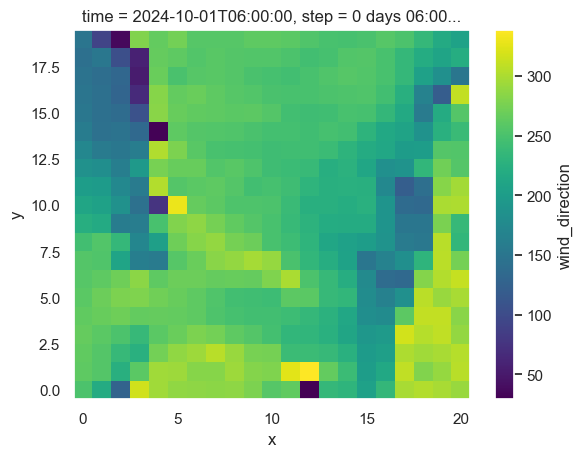

In [4]:
filepath = "/hdd/snow_hydrology/hrrrak/netcdf/"
filename = "hrrrak_merged_grib_f567_WY2025_test1.nc"

# load data
ds_hrrr = xr.open_dataset(filepath + filename)
# ds_hrrr = ds_hrrr.rio.write_crs('EPSG:32608', inplace=True)  # EPSG:32608 is the UTM zone 8N, which is the zone for the Powderpatch area
ds_hrrr = ds_hrrr.rio.write_crs('EPSG:4326', inplace=True)  # the data is in lat/lon

# calculate wind speed from u and v components
ds_hrrr['wind_speed'] = np.sqrt(ds_hrrr['u10']**2 + ds_hrrr['v10']**2)

# implemented, 
ds_hrrr["wind_direction"] = (180 * np.arctan2(ds_hrrr["u10"], ds_hrrr["v10"]) / np.pi)
ds_hrrr["wind_direction"] = (ds_hrrr["wind_direction"]+360) % 360 # convert to compass bearing 
ds_hrrr["wind_direction"][1].plot()

# Now we want to save a very simple version of a dataset, with only the wind speed and direction, for use in WindNinja.
# ds_hrrr_wind = ds_hrrr[["wind_speed", "wind_direction"]].copy()
ds_hrrr_wind = ds_hrrr[["u10", "v10", "wind_speed", "wind_direction"]].copy()
ds_hrrr_wind

Now, there is some dimension stuff to do

In [5]:
ds = ds_hrrr_wind.copy(deep=True) 

# Step 1: Rename dimensions if needed and set spatial dims
ds = ds.rename({'longitude': 'x', 'latitude': 'y'})
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')

# Step 2: Extract 1D x and y coordinates from the 2D grid
# Grab 1D x and y
x_1d = ds['x'].isel(y=0)  # same x values across rows
y_1d = ds['y'].isel(x=0)  # same y values down columns

# Assign 1D coords to the dataset
ds = ds.assign_coords(x=x_1d, y=y_1d)

# Step 3: Drop the 2D coords from the coordinate system
ds = ds.drop_vars(['x', 'y'])  # remove old 2D variables
ds = ds.set_coords([])         # ensure no unexpected spatial coords

# Step 4: Reassign the cleaned 1D coords
ds = ds.assign_coords({'x': x_1d, 'y': y_1d})

# Step 5: Now, reproject to UTM
# Now reproject to UTM
ds_utm = ds.rio.reproject("EPSG:32608")

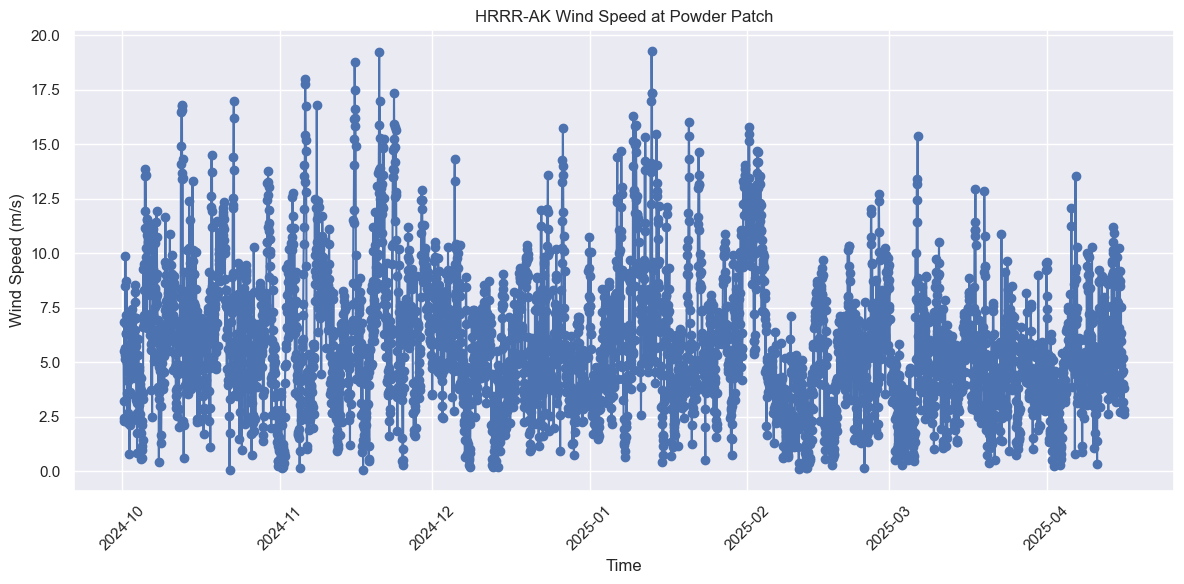

In [6]:
# Powder Patch Lat/Lon
lat_powderpatch = 58.26200
lon_powderpatch = -134.51700

# select the nearest grid point to the given lat/lon
ds_hrrr_wind_pp = ds_utm.sel(y=lat_powderpatch, x=lon_powderpatch, method='nearest') 

# and plot the timeseries 
plt.figure(figsize=(12, 6))
plt.plot(ds_hrrr_wind_pp['time'].values, ds_hrrr_wind_pp['wind_speed'].values, marker='o', linestyle='-', color='b')
plt.title('HRRR-AK Wind Speed at Powder Patch')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()

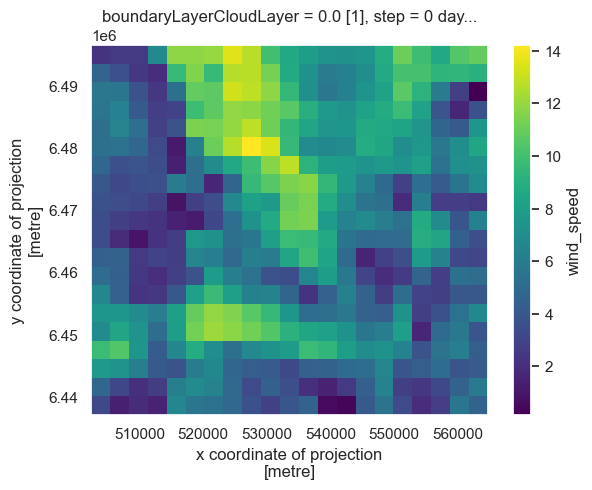

In [5]:
ds_utm['wind_speed'][1].plot()

Now, if we wanted to clip it, but maybe we do not need to do that since it needs to be larger than the DEM area. 

In [6]:
# # Transformer from WGS84 (lat/lon) to UTM Zone 8N
# transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)

# # # Input in (lon, lat) order for Powderpatch area
# # xmin_lon, ymin_lat = -134.594876, 58.238519
# # xmax_lon, ymax_lat = -134.445151, 58.308517

# # Clip over Juneau instead, because either way, the extent of the DEM determines the downscaled area
# # This bounding box is for the general Juneau region
# xmin_lon, xmax_lon = -134.964, -133.893
# ymin_lat, ymax_lat = 58.077, 58.603

# # Convert all corners
# xmin, ymin = transformer.transform(xmin_lon, ymin_lat)
# xmax, ymax = transformer.transform(xmax_lon, ymax_lat)

# print(f"UTM BBox: xmin={xmin:.2f}, xmax={xmax:.2f}, ymin={ymin:.2f}, ymax={ymax:.2f}")

# # clip everything
# ds_utm_clipped = ds_utm.rio.clip_box(minx=xmin, miny=ymin, maxx=xmax, maxy=ymax)

In [7]:
# now save this to a new netcdf file for later use
# output_nc_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_powderpatch_utm.nc" # this if we clipped around Powder Patch
# output_nc_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_juneau_utm.nc" # this if we clipped around Juneau
# ds_utm_clipped.to_netcdf(output_nc_file)

output_nc_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm.nc" # not clipped
ds_utm.to_netcdf(output_nc_file)

In [8]:
# now, cut the netcdf to just 1 month of data for testing
# time_start = np.datetime64('2024-11-01T00:00:00')
# time_end = np.datetime64('2024-12-01T00:00:00')
time_start = np.datetime64('2024-11-01T00:00:00')
time_end = np.datetime64('2024-11-02T00:00:00')

# if we clipped
# ds_utm_clipped = ds_utm_clipped.sel(time=slice(time_start, time_end))
# output_nc_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_juneau_utm_2daysonly.nc"
# ds_utm_clipped.to_netcdf(output_nc_file)

# if we do not clip
ds_utm = ds_utm.sel(time=slice(time_start, time_end))
# output_nc_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_2daysonly.nc"
# output_nc_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_1monthonly.nc"
output_nc_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_1dayonly.nc"

ds_utm.to_netcdf(output_nc_file)

In [9]:
# In the asci files for Wind Ninja, xll corner is xmin and yll corner is ymin
# print the corners of the UTM dataset
bounds = ds_utm.rio.bounds()
print(f"UTM Dataset Bounds: xmin={bounds[0]:.2f}, ymin={bounds[1]:.2f}, xmax={bounds[2]:.2f}, ymax={bounds[3]:.2f}")

UTM Dataset Bounds: xmin=502398.43, ymin=6437152.40, xmax=564756.02, ymax=6496540.58


In [10]:
bounds = ds_utm.rio.bounds()
xllcorner = bounds[0]
yllcorner = bounds[1]

### Check the DEM Domain

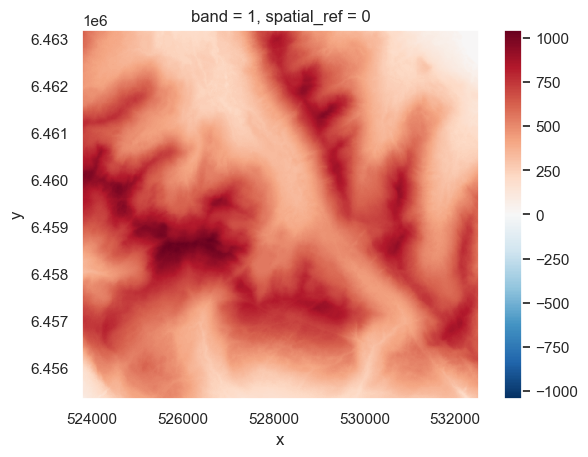

In [ ]:
# DEM_FILE = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_10m_UTM_clip_powderpatch_filled_gdal.tif"

# # open the DEM 
# dem = rioxarray.open_rasterio(DEM_FILE, masked=True)
# dem.plot()

________

# Run Wind Ninja

✅ Step 1: Convert NetCDF to .asc files per timestep

Each .asc will need a header like before, 

I’ll write a function that:

Reads each timestep of wind_speed and wind_direction.

Saves them to .asc files with the timestamp in the filename.

Returns a list of generated filenames.

✅ Step 2: Run WindNinja CLI for each timestep

We'll write a script to:

Copy the base config.

Update the input_wind_filename in the config to the .asc just made.

Run WindNinja using subprocess.

✅ Step 3: Zip results per batch

After WindNinja finishes, we zip the result directories.

___________

This script, 
* Extracts wind data from a NetCDF timeseries.
* Converts each timestep into .asc files for WindNinja.
* Runs WindNinja for each timestep using a config template.
* Zips all output folders into one archive.

In [12]:
import os
import xarray as xr
import numpy as np
import subprocess
from zipfile import ZipFile
from datetime import datetime

# ==== USER SETTINGS (EDIT HERE) ====
# NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1.nc"
# NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_juneau_utm.nc"
# NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_2daysonly.nc" # this is just a day or two of data for testing
NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_1monthonly.nc" # now redoing this same set up with 1 month of data to check the timeseries
NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_1dayonly.nc" # now redoing this same set up with 1 month of data to check the timeseries
DEM_FILE = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_10m_UTM_clip_powderpatch_filled_gdal.tif"
WINDNINJA_CONFIG = "/hdd/snow_hydrology/wind_ninja/test8/test8_config_template.cfg" # this is the one with placeholders
OUTPUT_DIR = "/hdd/snow_hydrology/wind_ninja/test8/output"
TMP_ASC_DIR = "/hdd/snow_hydrology/wind_ninja/test8/input/ascii_inputs"
VARIABLES = {
    "speed": "wind_speed",
    "direction": "wind_direction"
}

# need to define the xll and yll corners from the dataset bounds
# open the netcdf to get the bounds
ds_netcdf = xr.open_dataset(NETCDF_FILE)
bounds = ds_netcdf.rio.bounds()

# these four settings are related to the wind field input data
XLLCORNER = bounds[0]  # change as needed, I need to automate this in the script to open the netcdf and get the bounds
YLLCORNER = bounds[1]  # depends on the input wind fields from the netcdf file 
CELLSIZE = 3000        # HRRR-AK input data is at 3km, but if it was something else, this should change with the wind field input data
NODATA_VALUE = -9999

# ===================================

def write_asc(data: np.ndarray, output_path: str, xll: float, yll: float, cellsize: float, nodata: float):
    nrows, ncols = data.shape
    header = (
        f"ncols         {ncols}\n"
        f"nrows         {nrows}\n"
        f"xllcorner     {xll}\n"
        f"yllcorner     {yll}\n"
        f"cellsize      {cellsize}\n"
        f"NODATA_value  {nodata}\n"
    )
    with open(output_path, 'w') as f:
        f.write(header)
        for row in data:
            row_str = '\t'.join(f"{val:.2f}" if not np.isnan(val) else str(nodata) for val in row)
            f.write(row_str + '\n')

# ===================================

def generate_ascii_files(ds):
    os.makedirs(TMP_ASC_DIR, exist_ok=True)
    ascii_file_pairs = []

    # Projection string for .prj files (UTM Zone 8N)
    prj_contents = (
        'PROJCS["WGS_1984_UTM_Zone_8N",'
        'GEOGCS["GCS_WGS_1984",'
        'DATUM["D_WGS_1984",'
        'SPHEROID["WGS_1984",6378137.0,298.257223563]],'
        'PRIMEM["Greenwich",0.0],'
        'UNIT["Degree",0.0174532925199433]],'
        'PROJECTION["Transverse_Mercator"],'
        'PARAMETER["False_Easting",500000.0],'
        'PARAMETER["False_Northing",0.0],'
        'PARAMETER["Central_Meridian",-135.0],'
        'PARAMETER["Scale_Factor",0.9996],'
        'PARAMETER["Latitude_Of_Origin",0.0],'
        'UNIT["Meter",1.0]]'
    )

    for i, t in enumerate(ds.time):
        timestamp = pd.to_datetime(str(t.values)).strftime("%Y%m%d_%H%M")
        speed_2d = ds[VARIABLES["speed"]].isel(time=i).values
        dir_2d = ds[VARIABLES["direction"]].isel(time=i).values

        speed_path = os.path.join(TMP_ASC_DIR, f"wind_speed_{timestamp}.asc")
        dir_path = os.path.join(TMP_ASC_DIR, f"wind_dir_{timestamp}.asc")

        # Write ASC files
        write_asc(speed_2d, speed_path, XLLCORNER, YLLCORNER, CELLSIZE, NODATA_VALUE)
        write_asc(dir_2d, dir_path, XLLCORNER, YLLCORNER, CELLSIZE, NODATA_VALUE)

        # Write corresponding PRJ files
        with open(speed_path.replace(".asc", ".prj"), 'w') as f:
            f.write(prj_contents)
        with open(dir_path.replace(".asc", ".prj"), 'w') as f:
            f.write(prj_contents)

        ascii_file_pairs.append((timestamp, speed_path, dir_path))

    return ascii_file_pairs

# ===================================

def run_windninja(speed_path, dir_path, timestamp):
    output_subdir = os.path.join(OUTPUT_DIR, f"windninja_{timestamp}")
    os.makedirs(output_subdir, exist_ok=True)

    config_path = os.path.join(output_subdir, f"config_{timestamp}.cfg")
    with open(WINDNINJA_CONFIG, 'r') as f:
        config = f.read()

    config = config.replace("INPUT_SPEED_FILE", speed_path)
    config = config.replace("INPUT_DIR_FILE", dir_path)
    config = config.replace("INPUT_DEM_FILE", DEM_FILE)
    config = config.replace("OUTPUT_PATH", output_subdir)

    with open(config_path, 'w') as f:
        f.write(config)

    # Run WindNinja via Docker
    docker_command = [
        "docker", "run", "--rm",
        "-v", "/hdd:/hdd",
        "windninja:latest",
        "WindNinja_cli", config_path
    ]
    subprocess.run(docker_command, check=True)

# ===================================

def zip_outputs():
    zipf = ZipFile(f"{OUTPUT_DIR}.zip", 'w')
    for root, _, files in os.walk(OUTPUT_DIR):
        for file in files:
            filepath = os.path.join(root, file)
            zipf.write(filepath, os.path.relpath(filepath, OUTPUT_DIR))
    zipf.close()

# ===================================

def main():
    ds = xr.open_dataset(NETCDF_FILE)
    ascii_files = generate_ascii_files(ds)
    for timestamp, speed, direction in ascii_files:
        print(f"Processing timestep {timestamp}")
        run_windninja(speed, direction, timestamp)
    zip_outputs()
    print("All done. Output zipped.")

if __name__ == "__main__":
    import pandas as pd
    main()

Processing timestep 20241101_0000


ERROR 1: Connection timed out after 5001 milliseconds


Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Building equations...
Run 0: Solving...
Run 0 (solver): 2% complete
Run 0 (solver): 2% complete
Run 0 (solver): 64% complete
Run 0 (solver): 99% complete
Run 0 (solver): 100% complete
Run 0: Writing output files...
Run 0: Meshing time was 0.006969 seconds.
Run 0: Initialization time was 0.003388 seconds.
Run 0: Equation building time was 0.001850 seconds.
Run 0: Solver time was 0.006869 seconds.
Run 0: Output writing time was 0.028159 seconds.
Run 0: Total simulation time was 0.047972 seconds.
Run 0: Run number 0 done!
Processing timestep 20241101_0100


ERROR 1: Connection timed out after 5001 milliseconds


Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Building equations...
Run 0: Solving...
Run 0 (solver): 2% complete
Run 0 (solver): 2% complete
Run 0 (solver): 74% complete
Run 0 (solver): 96% complete
Run 0 (solver): 100% complete
Run 0: Writing output files...
Run 0: Meshing time was 0.006900 seconds.
Run 0: Initialization time was 0.003429 seconds.
Run 0: Equation building time was 0.001695 seconds.
Run 0: Solver time was 0.006962 seconds.
Run 0: Output writing time was 0.026988 seconds.
Run 0: Total simulation time was 0.046696 seconds.
Run 0: Run number 0 done!
Processing timestep 20241101_0200


...

Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Building equations...
Run 0: Solving...
Run 0 (solver): 2% complete
Run 0 (solver): 4% complete
Run 0 (solver): 84% complete
Run 0 (solver): 98% complete
Run 0 (solver): 100% complete
Run 0: Writing output files...
Run 0: Meshing time was 0.007697 seconds.
Run 0: Initialization time was 0.003703 seconds.
Run 0: Equation building time was 0.001721 seconds.
Run 0: Solver time was 0.007182 seconds.
Run 0: Output writing time was 0.027312 seconds.
Run 0: Total simulation time was 0.048357 seconds.
Run 0: Run number 0 done!
Processing timestep 20241101_2300


ERROR 1: Connection timed out after 5000 milliseconds


Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Building equations...
Run 0: Solving...
Run 0 (solver): 2% complete
Run 0 (solver): 2% complete
Run 0 (solver): 81% complete
Run 0 (solver): 99% complete
Run 0 (solver): 100% complete
Run 0: Writing output files...
Run 0: Meshing time was 0.007627 seconds.
Run 0: Initialization time was 0.003383 seconds.
Run 0: Equation building time was 0.001758 seconds.
Run 0: Solver time was 0.006604 seconds.
Run 0: Output writing time was 0.014863 seconds.
Run 0: Total simulation time was 0.034957 seconds.
Run 0: Run number 0 done!
Processing timestep 20241102_0000


ERROR 1: Connection timed out after 5001 milliseconds


Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Building equations...
Run 0: Solving...
Run 0 (solver): 2% complete
Run 0 (solver): 2% complete
Run 0 (solver): 81% complete
Run 0 (solver): 99% complete
Run 0 (solver): 100% complete
Run 0: Writing output files...
Run 0: Meshing time was 0.006894 seconds.
Run 0: Initialization time was 0.003391 seconds.
Run 0: Equation building time was 0.001690 seconds.
Run 0: Solver time was 0.006861 seconds.
Run 0: Output writing time was 0.027400 seconds.
Run 0: Total simulation time was 0.046984 seconds.
Run 0: Run number 0 done!
All done. Output zipped.


# Move to next script to read the output... `3_read_wind_ninja_output_ascii.ipynb`

A few things, 
* this is running quite slow, I could run each timestep in parallel... but currently it just goes hour by hour
* I could make it an .sh file or .py file to run in the future without all the print outs 
* There is also an error code: `ERROR01: Connection timed out after 5001 milliseconds` so I'm not sure what that's about... but it seems to be working fine. 

### Now, for handling the output 
* everything is in kmz files... we need to figure out the best way to handle those to look at the downscaled wind fields 

_________________________

## Here is a version of the script to run in parallel

In [11]:
import os
import xarray as xr
import numpy as np
import subprocess
from zipfile import ZipFile
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed
import pandas as pd
import rasterio

# ==== USER SETTINGS ====
NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_1monthonly.nc"
# NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm.nc" # this is for a few months, let's run it 
DEM_FILE = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_10m_UTM_clip_powderpatch_filled_gdal.tif"
WINDNINJA_CONFIG = "/hdd/snow_hydrology/wind_ninja/test6/test6_config_template.cfg"
OUTPUT_DIR = "/hdd/snow_hydrology/wind_ninja/test6/output"
TMP_ASC_DIR = "/hdd/snow_hydrology/wind_ninja/test6/input/ascii_inputs"
VARIABLES = {"speed": "wind_speed", "direction": "wind_direction"}

MAX_PARALLEL_JOBS = 10  # number of simultaneous WindNinja jobs

# ========================

def write_asc(data: np.ndarray, output_path: str, xll: float, yll: float, cellsize: float, nodata: float):
    nrows, ncols = data.shape
    header = (
        f"ncols         {ncols}\n"
        f"nrows         {nrows}\n"
        f"xllcorner     {xll}\n"
        f"yllcorner     {yll}\n"
        f"cellsize      {cellsize}\n"
        f"NODATA_value  {nodata}\n"
    )
    with open(output_path, 'w') as f:
        f.write(header)
        for row in data:
            row_str = '\t'.join(f"{val:.2f}" if not np.isnan(val) else str(nodata) for val in row)
            f.write(row_str + '\n')

def generate_ascii_files(ds, xll, yll, cellsize, nodata):
    os.makedirs(TMP_ASC_DIR, exist_ok=True)
    ascii_file_pairs = []
    prj_contents = (
        'PROJCS["WGS_1984_UTM_Zone_8N",'
        'GEOGCS["GCS_WGS_1984",'
        'DATUM["D_WGS_1984",'
        'SPHEROID["WGS_1984",6378137.0,298.257223563]],'
        'PRIMEM["Greenwich",0.0],'
        'UNIT["Degree",0.0174532925199433]],'
        'PROJECTION["Transverse_Mercator"],'
        'PARAMETER["False_Easting",500000.0],'
        'PARAMETER["False_Northing",0.0],'
        'PARAMETER["Central_Meridian",-135.0],'
        'PARAMETER["Scale_Factor",0.9996],'
        'PARAMETER["Latitude_Of_Origin",0.0],'
        'UNIT["Meter",1.0]]'
    )

    for i, t in enumerate(ds.time):
        timestamp = pd.to_datetime(str(t.values)).strftime("%Y%m%d_%H%M")
        speed_2d = ds[VARIABLES["speed"]].isel(time=i).values
        dir_2d = ds[VARIABLES["direction"]].isel(time=i).values

        speed_path = os.path.join(TMP_ASC_DIR, f"wind_speed_{timestamp}.asc")
        dir_path = os.path.join(TMP_ASC_DIR, f"wind_dir_{timestamp}.asc")

        write_asc(speed_2d, speed_path, xll, yll, cellsize, nodata)
        write_asc(dir_2d, dir_path, xll, yll, cellsize, nodata)

        with open(speed_path.replace(".asc", ".prj"), 'w') as f:
            f.write(prj_contents)
        with open(dir_path.replace(".asc", ".prj"), 'w') as f:
            f.write(prj_contents)

        ascii_file_pairs.append((timestamp, speed_path, dir_path))

    return ascii_file_pairs


def run_windninja(speed_path, dir_path, timestamp):
    output_subdir = os.path.join(OUTPUT_DIR, f"windninja_{timestamp}")
    os.makedirs(output_subdir, exist_ok=True)

    config_path = os.path.join(output_subdir, f"config_{timestamp}.cfg")
    with open(WINDNINJA_CONFIG, 'r') as f:
        config = f.read()

    config = config.replace("INPUT_SPEED_FILE", speed_path)
    config = config.replace("INPUT_DIR_FILE", dir_path)
    config = config.replace("INPUT_DEM_FILE", DEM_FILE)
    config = config.replace("OUTPUT_PATH", output_subdir)

    with open(config_path, 'w') as f:
        f.write(config)

    docker_command = [
        "docker", "run", "--rm",
        "-v", "/hdd:/hdd",
        "windninja:latest",
        "WindNinja_cli", config_path
    ]

    try:
        subprocess.run(docker_command, check=True)
        print(f"✅ Completed {timestamp}")
    except subprocess.CalledProcessError as e:
        print(f"⚠️ Failed {timestamp}: {e}")


def main():
    ds = xr.open_dataset(NETCDF_FILE)
    bounds = ds.rio.bounds()
    xll, yll = bounds[0], bounds[1]
    cellsize = 3000
    nodata = -9999

    ascii_files = generate_ascii_files(ds, xll, yll, cellsize, nodata)

    with ProcessPoolExecutor(max_workers=MAX_PARALLEL_JOBS) as executor:
        futures = [executor.submit(run_windninja, s, d, t)
                   for t, s, d in ascii_files]
        for future in as_completed(futures):
            _ = future.result()

    print("🎉 All WindNinja runs completed.")


if __name__ == "__main__":
    main()

ERROR 1: Connection timed out after 5001 milliseconds
ERROR 1: Connection timed out after 5000 milliseconds
ERROR 1: Connection timed out after 5001 milliseconds
ERROR 1: Connection timed out after 5000 milliseconds
ERROR 1: Connection timed out after 5001 milliseconds


Run 0: Reading elevation file...
Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Reading elevation file...
Run 0: Initializing flow...
Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Reading elevation file...
Run 0: Initializing flow...


ERROR 1: Connection timed out after 5001 milliseconds
ERROR 1: Connection timed out after 5001 milliseconds
ERROR 1: Connection timed out after 5001 milliseconds
ERROR 1: Connection timed out after 5000 milliseconds
ERROR 1: Connection timed out after 5001 milliseconds


Run 0: Building equations...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Building equations...
Run 0: Reading elevation file...
Run 0: Reading elevation file...
Run 0: Initializing flow...
Run 0: Initializing flow...
Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Building equations...
Run 0: Reading elevation file...
Run 0: Initializing flow...
Run 0: Initializing flow...
Run 0: Reading elevation file...
Run 0: Building equations...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Building equations...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Initializing flow...
Run 

ERROR 1: Connection timed out after 5001 milliseconds


...

Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Building equations...


ERROR 1: Connection timed out after 5001 milliseconds
ERROR 1: Connection timed out after 5000 milliseconds
ERROR 1: Connection timed out after 5001 milliseconds
ERROR 1: Connection timed out after 5000 milliseconds


Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Reading elevation file...
Run 0: Initializing flow...
Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Reading elevation file...
Run 0: Initializing flow...
Run 0: Building equations...
Run 0: Solving...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Building equations...
Run 0: Building equations...
Run 0: Reading elevation file...
Run 0: Building equations...


ERROR 1: Connection timed out after 5000 milliseconds
ERROR 1: Connection timed out after 5001 milliseconds


Run 0: Reading elevation file...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Run number 0 started with 2 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Run 0: Building equations...
Run 0: Building equations...
Run 0: Solving...
Run 0 (solver): 26% complete
Run 0: Solving...
Run 0: Solving...
Run 0: Solving...
Run 0: Solving...
Run 0: Solving...
Run 0 (solver): 52% complete
Run 0 (solver): 26% complete
Run 0 (solver): 26% complete
Run 0 (solver): 25% complete
Run 0 (solver): 25% complete
Run 0 (solver): 26% complete
Run 0 (solver): 27% complete
Run 0 (solver): 68% complete
Run 0 (solver): 52% complete
Run 0 (solver): 52% complete
Run 0 (solver): 52% complete
Run 0 (solver): 52% complete
Run 0 (solver): 52% complete
Run 0 (solver): 53% complete
Run 0 (solver): 82% complete
Run 0 (solver): 68% complete
Run 0 (solver): 67% complete
Run 0 (solver): 68% complete
Run 0 (solver): 69% complete
Run 0 (solver): 69% compl